In [18]:
!pip install datasets

from datasets import load_dataset
import pandas as pd

# Load dataset
dataset = load_dataset("amazon_polarity")

# Convert train split to pandas
df = dataset["train"].to_pandas()

# Show data
print(df.head())

   label                                              title  \
0      1                     Stuning even for the non-gamer   
1      1              The best soundtrack ever to anything.   
2      1                                           Amazing!   
3      1                               Excellent Soundtrack   
4      1  Remember, Pull Your Jaw Off The Floor After He...   

                                             content  
0  This sound track was beautiful! It paints the ...  
1  I'm reading a lot of reviews saying that this ...  
2  This soundtrack is my favorite music of all ti...  
3  I truly like this soundtrack and I enjoy video...  
4  If you've played the game, you know how divine...  


In [19]:
# Install datasets library
!pip install datasets gensim

# Load Amazon Polarity Dataset
from datasets import load_dataset
import pandas as pd

dataset = load_dataset("amazon_polarity")

# Convert to pandas
train_df = dataset["train"].to_pandas()
test_df = dataset["test"].to_pandas()

# Merge train + test
df = pd.concat([train_df, test_df], ignore_index=True)

# Keep required columns
df = df[['content', 'label']]

# Rename columns
df.columns = ['review', 'label']

# Create sentiment column
df['sentiment'] = df['label'].map({
    0: 'negative',
    1: 'positive'
})

# Optional: Use smaller dataset for faster training
df = df.sample(50000, random_state=42)

print(df.shape)

df.head()

(50000, 3)


,review,label,sentiment
1049554,"The book delves very little into art, aside fr...",0,negative
214510,"In ""The Limits of State Action"" Enlightenment ...",1,positive
2145764,"""In vain did the Bedouins strive to cut down a...",1,positive
2198867,"wow, that was bad, I threw it away after watch...",0,negative
1184366,i just finished reading Someone Like You and i...,1,positive


In [20]:
from gensim.models import Word2Vec

In [21]:

# LOAD AMAZON DATASET

dataset = load_dataset("amazon_polarity")

train_df = dataset["train"].to_pandas()
test_df = dataset["test"].to_pandas()

# Merge datasets
df = pd.concat([train_df, test_df], ignore_index=True)

# Keep required columns
df = df[['content', 'label']]

# Rename columns
df.columns = ['review', 'label']

# Create sentiment column
df['sentiment'] = df['label'].map({
    0: 'negative',
    1: 'positive'
})



df = df.sample(50000, random_state=RANDOM_STATE)

print("Dataset Shape:", df.shape)

df.head()

# TEXT CLEANING


stop_words = set(stopwords.words('english'))

negation_words = {
    'no',
    'not',
    'nor',
    'never',
    'none',
    'cannot'
}

stop_words = stop_words - negation_words

lemmatizer = WordNetLemmatizer()

def clean_review(text):

    text = BeautifulSoup(
        str(text),
        'html.parser'
    ).get_text(separator=' ')

    text = text.lower()

    text = re.sub(r'[^a-z\s]', ' ', text)

    tokens = word_tokenize(text)

    tokens = [
        word
        for word in tokens
        if word not in stop_words
        and len(word) > 2
    ]

    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]

    return ' '.join(tokens)

# Apply cleaning
df['clean_review'] = df['review'].apply(clean_review)

print(df[['review', 'clean_review']].head())

# TOKENIZE FOR WORD2VEC


tokenized_reviews = [
    review.split()
    for review in df['clean_review']
]


Dataset Shape: (50000, 3)
                                                    review  \
1049554  The book delves very little into art, aside fr...   
214510   In "The Limits of State Action" Enlightenment ...   
2145764  "In vain did the Bedouins strive to cut down a...   
2198867  wow, that was bad, I threw it away after watch...   
1184366  i just finished reading Someone Like You and i...   

                                              clean_review  
1049554  book delf little art aside introducing roy biv...  
214510   limit state action enlightenment thinker wilhe...  
2145764  vain bedouin strive cut overpower two champion...  
2198867  wow bad threw away watching fast forwarded try...  
1184366  finished reading someone like fell love found ...  


In [22]:

# TRAIN CBOW MODEL


cbow_model = Word2Vec(
    sentences=tokenized_reviews,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=0
)

print("CBOW Vocabulary Size:",
      len(cbow_model.wv))

# TRAIN SKIP-GRAM MODEL


skipgram_model = Word2Vec(
    sentences=tokenized_reviews,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1
)

print("Skip-Gram Vocabulary Size:",
      len(skipgram_model.wv))

# TRAIN TEST SPLIT


X = df['clean_review']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

# TOKENIZATION FOR LSTM


MAX_WORDS = 20000
MAX_LEN = 200
EMBEDDING_DIM = 100

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token='<OOV>'
)

tokenizer.fit_on_texts(X_train)

# Convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Padding
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

print("Train Shape:", X_train_pad.shape)
print("Test Shape:", X_test_pad.shape)


CBOW Vocabulary Size: 34059
Skip-Gram Vocabulary Size: 34059
Training Samples: 40000
Testing Samples: 10000
Train Shape: (40000, 200)
Test Shape: (10000, 200)


In [23]:

# CREATE EMBEDDING MATRIX


def create_embedding_matrix(
    word2vec_model,
    tokenizer,
    max_words,
    embedding_dim
):

    embedding_matrix = np.zeros(
        (max_words, embedding_dim)
    )

    for word, index in tokenizer.word_index.items():

        if index < max_words:

            if word in word2vec_model.wv:

                embedding_matrix[index] = (
                    word2vec_model.wv[word]
                )

    return embedding_matrix

# CREATE CBOW MATRIX


cbow_embedding_matrix = create_embedding_matrix(
    cbow_model,
    tokenizer,
    MAX_WORDS,
    EMBEDDING_DIM
)


# CREATE SKIPGRAM MATRIX


skipgram_embedding_matrix = create_embedding_matrix(
    skipgram_model,
    tokenizer,
    MAX_WORDS,
    EMBEDDING_DIM
)


In [24]:

# BUILD LSTM MODEL


def build_lstm_model(embedding_matrix):

    model = Sequential([

        Embedding(
            input_dim=MAX_WORDS,
            output_dim=EMBEDDING_DIM,
            weights=[embedding_matrix],
            input_length=MAX_LEN,
            trainable=False
        ),

        Bidirectional(
            LSTM(
                64,
                dropout=0.3,
                recurrent_dropout=0.3
            )
        ),

        Dense(32, activation='relu'),

        Dropout(0.5),

        Dense(1, activation='sigmoid')

    ])

    model.compile(
        loss='binary_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )

    return model


In [25]:

# EVALUATION FUNCTION

def evaluate_model(model_name,
                   y_true,
                   y_pred):

    print("\n", "="*50)
    print(model_name)
    print("="*50)

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=[
                'negative',
                'positive'
            ]
        )
    )

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred
    )

    recall = recall_score(
        y_true,
        y_pred
    )

    f1 = f1_score(
        y_true,
        y_pred
    )

    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))

    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    }


# EARLY STOPPING


early_stop = EarlyStopping(
    monitor='val_loss',
    patience=1,
    restore_best_weights=True
)

In [26]:

# CBOW + LSTM


print("\nTraining CBOW + LSTM Model...")

cbow_lstm_model = build_lstm_model(
    cbow_embedding_matrix
)

history_cbow = cbow_lstm_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

# Predictions
cbow_prob = cbow_lstm_model.predict(
    X_test_pad
)

cbow_pred = (
    cbow_prob >= 0.5
).astype(int).reshape(-1)

# Evaluation
cbow_results = evaluate_model(
    'CBOW + LSTM',
    y_test,
    cbow_pred
)



Training CBOW + LSTM Model...
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


250/250 ━━━━━━━━━━━━━━━━━━━━ 182s 702ms/step - accuracy: 0.7228 - loss: 0.5503 - val_accuracy: 0.7993 - val_loss: 0.4450
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 167s 669ms/step - accuracy: 0.7839 - loss: 0.4712 - val_accuracy: 0.8142 - val_loss: 0.4071
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 218s 735ms/step - accuracy: 0.8037 - loss: 0.4365 - val_accuracy: 0.8250 - val_loss: 0.3906
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 188s 678ms/step - accuracy: 0.8123 - loss: 0.4145 - val_accuracy: 0.8282 - val_loss: 0.3825
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 202s 679ms/step - accuracy: 0.8209 - loss: 0.4063 - val_accuracy: 0.8314 - val_loss: 0.3818
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 94ms/step

CBOW + LSTM
              precision    recall  f1-score   support

    negative       0.85      0.82      0.83      5004
    positive       0.82      0.85      0.84      4996

    accuracy                           0.83     10000
   macro avg       0.84      0.84      0.83     10000
weighted avg       0.84    

In [32]:

# SKIPGRAM + LSTM


print("\nTraining Skip-Gram + LSTM Model...")

skipgram_lstm_model = build_lstm_model(
    skipgram_embedding_matrix
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_skipgram = skipgram_lstm_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

# Predictions
skipgram_prob = skipgram_lstm_model.predict(
    X_test_pad
)

skipgram_pred = (
    skipgram_prob >= 0.5
).astype(int).reshape(-1)

# Evaluation
skipgram_results = evaluate_model(
    'SkipGram + LSTM',
    y_test,
    skipgram_pred
)

# RESULTS COMPARISON


results_df = pd.DataFrame([
    cbow_results,
    skipgram_results
])

print("\nFinal Results")
print(results_df)


Training Skip-Gram + LSTM Model...
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


250/250 ━━━━━━━━━━━━━━━━━━━━ 187s 710ms/step - accuracy: 0.7022 - loss: 0.5765 - val_accuracy: 0.7965 - val_loss: 0.4548
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 192s 670ms/step - accuracy: 0.7608 - loss: 0.5126 - val_accuracy: 0.8094 - val_loss: 0.4328
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 176s 703ms/step - accuracy: 0.7834 - loss: 0.4767 - val_accuracy: 0.8206 - val_loss: 0.4114
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 177s 710ms/step - accuracy: 0.7953 - loss: 0.4501 - val_accuracy: 0.8234 - val_loss: 0.4000
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 201s 705ms/step - accuracy: 0.8053 - loss: 0.4317 - val_accuracy: 0.8315 - val_loss: 0.3872
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 92ms/step

SkipGram + LSTM
              precision    recall  f1-score   support

    negative       0.85      0.81      0.83      5004
    positive       0.81      0.86      0.84      4996

    accuracy                           0.83     10000
   macro avg       0.83      0.83      0.83     10000
weighted avg       0.83

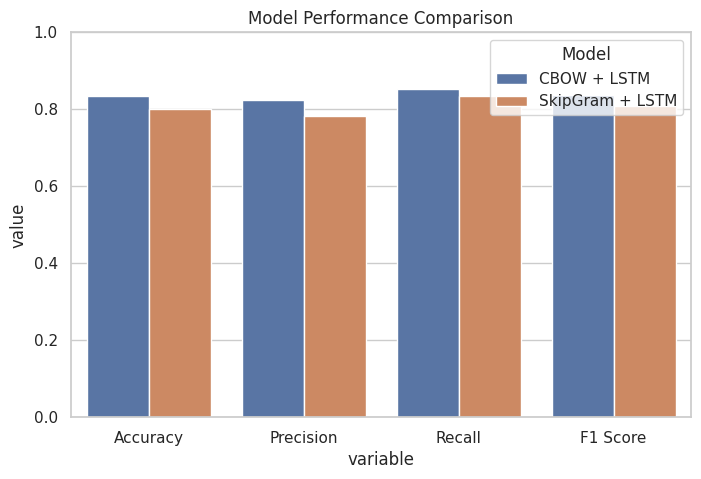

In [28]:

# PLOT RESULTS

plt.figure(figsize=(8,5))

metrics_df = results_df.melt(
    id_vars='Model',
    value_vars=[
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ]
)

sns.barplot(
    data=metrics_df,
    x='variable',
    y='value',
    hue='Model'
)

plt.title("Model Performance Comparison")

plt.ylim(0, 1)

plt.show()


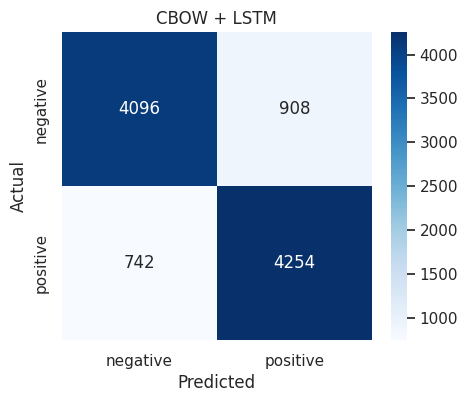

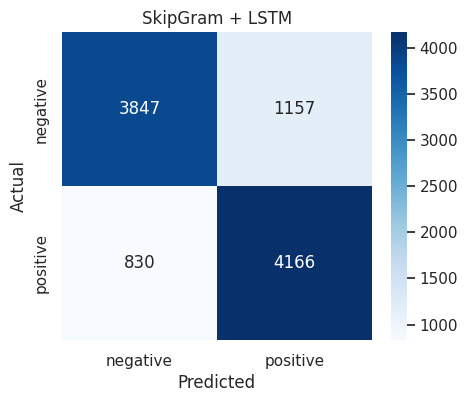

In [29]:

# CONFUSION MATRIX


def plot_confusion_matrix(y_true,
                          y_pred,
                          title):

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=[
            'negative',
            'positive'
        ],
        yticklabels=[
            'negative',
            'positive'
        ]
    )

    plt.title(title)

    plt.xlabel('Predicted')

    plt.ylabel('Actual')

    plt.show()

plot_confusion_matrix(
    y_test,
    cbow_pred,
    'CBOW + LSTM'
)

plot_confusion_matrix(
    y_test,
    skipgram_pred,
    'SkipGram + LSTM'
)


In [30]:

# TEST CUSTOM REVIEW


sample_review = """
This product quality is amazing.
Battery backup is excellent and
I really loved it.
"""

# Clean review
sample_clean = clean_review(
    sample_review
)

# Convert to sequence
sample_seq = tokenizer.texts_to_sequences(
    [sample_clean]
)

sample_pad = pad_sequences(
    sample_seq,
    maxlen=MAX_LEN,
    padding='post'
)

# Predict using CBOW model
cbow_prediction = (
    cbow_lstm_model.predict(sample_pad)[0][0]
)



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


In [31]:
# Predict using SkipGram model
skipgram_prediction = (
    skipgram_lstm_model.predict(sample_pad)[0][0]
)

print("\nSample Review:")
print(sample_review)

print("\nClean Review:")
print(sample_clean)

print("\nCBOW Prediction:")
print(
    "Positive"
    if cbow_prediction >= 0.5
    else "Negative"
)

print("Probability:",
      round(float(cbow_prediction), 4))

print("\nSkipGram Prediction:")
print(
    "Positive"
    if skipgram_prediction >= 0.5
    else "Negative"
)

print("Probability:",
      round(float(skipgram_prediction), 4))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step

Sample Review:

This product quality is amazing.
Battery backup is excellent and
I really loved it.


Clean Review:
product quality amazing battery backup excellent really loved

CBOW Prediction:
Positive
Probability: 0.985

SkipGram Prediction:
Positive
Probability: 0.8193
